# COLAB 2: Processing multi-subject datasets with high-performance computing

## Course architecture

Data acquisition ➡️ Training an ML model ➡️ Visualizing results ➡️ Documenting research

## Instructions for the student
In this lab, you will train a machine learning (ML) model (convolutional neural network, CNN) on temporal EEG data recorded from multiple subjects and channels.

Your objective is to pass the explicit **"AI Prompt Challenges"** directly to an AI coding assistant, evaluate the structural properties of the returned functions, and paste them into the designated code boundaries.

## Module 0: Setting up an environment on FABRIC

**Student AI prompt challenge**

Copy and paste the code block from the cell below and the following text block into your AI assistant:

> "Give me commands I can use in the ubuntu terminal to (1) install anaconda, (2) create a conda environment, (3) activate that environment, (4) install numpy, pandas, matplotlib, pytorch (GPU-compatible)."

## Module 1: Data acquisition

We will continue working with the [EEG Emotion Recognition dataset](https://www.kaggle.com/datasets/wajahat1064/emotion-recognition-using-eeg-and-computer-games?resource=download), acquiring data from all 28 subjects. The cells below download the full dataset from Kaggle.

In [68]:
import os
import kagglehub

# Download from kaggle
root = kagglehub.dataset_download("wajahat1064/emotion-recognition-using-eeg-and-computer-games")
print("Dataset downloaded to:", root)

# Locate the GAMEEMO folder instead of hard-coding the long nested path,
# so the code keeps working if the dataset version / folder names change.
path = None
for dirpath, dirnames, filenames in os.walk(root):
    if os.path.basename(dirpath) == "GAMEEMO":
        path = dirpath
        break

assert path is not None, f"Could not find a GAMEEMO folder under {root}"
print("Using data path:", path)
print("Contains:", sorted(os.listdir(path))[:5], "...")


Using Colab cache for faster access to the 'emotion-recognition-using-eeg-and-computer-games' dataset.
Dataset downloaded to: /kaggle/input/emotion-recognition-using-eeg-and-computer-games
Using data path: /kaggle/input/emotion-recognition-using-eeg-and-computer-games/Dataset - Emotion Recognition data Based on EEG Signals and Computer Games/Database for Emotion Recognition System Based on EEG Signals and Various Computer Games - GAMEEMO/GAMEEMO
Contains: ['(S01)', '(S02)', '(S03)', '(S04)', '(S05)'] ...


**Student AI prompt challenge**

The `subjects` variable below should hold subject identifiers from the dataset (S01-S28). Design a prompt and define this variable with the AI.

In [69]:
#TODO: your code here
# Subject identifiers S01 ... S28 (zero-padded to two digits)
subjects = [f"S{i:02d}" for i in range(1, 29)]
print(subjects)


['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'S19', 'S20', 'S21', 'S22', 'S23', 'S24', 'S25', 'S26', 'S27', 'S28']


In [70]:
print(len(subjects))

28


The functions below read data from a single subjects and combine the resulting dataset into an array of size (subjects x game_types x channels x time).

In [71]:
import glob
import numpy as np
import pandas as pd


def read_subject(subject, path):
    """Read one subject's 4 game recordings -> (game_types x channels x time)."""
    csv_files = sorted(glob.glob(os.path.join(path, "*.csv")))
    assert len(csv_files) == 4, (
        f"Expected 4 csv files for {subject} in {path}, found {len(csv_files)}"
    )

    subject_recordings = []
    for game_idx in range(4):
        # Read channel x time data
        csv_filename = f"{subject}G{game_idx + 1}AllChannels.csv"
        df = pd.read_csv(os.path.join(path, csv_filename))

        # Drop the trailing empty column ("Unnamed: 14") if pandas created one.
        # Using a filter instead of a hard-coded name avoids a KeyError when the
        # column is absent.
        df = df.loc[:, ~df.columns.str.contains(r"^Unnamed")]

        # Shape into a channels x time array
        subject_recordings.append(df.to_numpy().T)

    # Shape into game_types x channels x time
    subject_recordings = np.stack(subject_recordings)

    return subject_recordings


def find_subject_path(subject, path):
    """Return the folder holding a subject's preprocessed .csv files.

    Folder naming is not perfectly consistent across subjects, so we search for
    the '.csv format' directory rather than assuming a fixed layout.
    """
    subject_dir = os.path.join(path, f"({subject})")
    if not os.path.isdir(subject_dir):
        raise FileNotFoundError(f"No directory for subject {subject}: {subject_dir}")

    for dirpath, dirnames, filenames in os.walk(subject_dir):
        if sum(f.lower().endswith(".csv") for f in filenames) == 4:
            return dirpath

    raise FileNotFoundError(
        f"Could not find a folder with 4 .csv files for subject {subject} "
        f"under {subject_dir}"
    )


def read_subjects(subjects, path):
    """Read many subjects -> (subjects x game_types x channels x time)."""
    all_recordings = []
    for subject in subjects:
        subject_path = find_subject_path(subject, path)
        data = read_subject(subject, subject_path)
        all_recordings.append(data)

    # Subjects x game_types x channels x time
    all_recordings = np.stack(all_recordings)
    return all_recordings


In [72]:
data = read_subjects(subjects, path)

**Student AI prompt challenge**

As you can see, there is an error when reading data of one of the subjects. Design a prompt to list the contents of the subject's directory and compare the contents with antoher subject (e.g., subject S01). What is the problem?

In [73]:
#TODO: your code here: list the contents of S26's directory and compare with S01
# Compare the directory trees of S26 and S01 to see why S26 fails
def show_tree(subject, path, max_files=10):
    subject_dir = os.path.join(path, f"({subject})")
    print(f"\n=== {subject}: {subject_dir} ===")
    if not os.path.isdir(subject_dir):
        print("  !! directory does not exist")
        return
    for dirpath, dirnames, filenames in os.walk(subject_dir):
        rel = os.path.relpath(dirpath, subject_dir)
        rel = "." if rel == "." else rel
        print(f"  [dir] {rel}  ({len(filenames)} files)")
        for f in sorted(filenames)[:max_files]:
            print(f"        - {f}")
        if len(filenames) > max_files:
            print(f"        ... and {len(filenames) - max_files} more")


show_tree("S01", path)
show_tree("S26", path)



=== S01: /kaggle/input/emotion-recognition-using-eeg-and-computer-games/Dataset - Emotion Recognition data Based on EEG Signals and Computer Games/Database for Emotion Recognition System Based on EEG Signals and Various Computer Games - GAMEEMO/GAMEEMO/(S01) ===
  [dir] .  (0 files)
  [dir] Preprocessed EEG Data  (0 files)
  [dir] Preprocessed EEG Data/.mat format  (4 files)
        - S01G1AllChannels.mat
        - S01G2AllChannels.mat
        - S01G3AllChannels.mat
        - S01G4AllChannels.mat
  [dir] Preprocessed EEG Data/.csv format  (4 files)
        - S01G1AllChannels.csv
        - S01G2AllChannels.csv
        - S01G3AllChannels.csv
        - S01G4AllChannels.csv
  [dir] SAM Ratings  (4 files)
        - G1.pdf
        - G2.pdf
        - G3.pdf
        - G4.pdf
  [dir] Raw EEG Data  (0 files)
  [dir] Raw EEG Data/.mat format  (4 files)
        - S01G1AllRawChannels.mat
        - S01G2AllRawChannels.mat
        - S01G3AllRawChannels.mat
        - S01G4AllRawChannels.mat
  [dir] R

**Student AI prompt challenge**

Prompt AI to modify the list of subjects to exclude subject 26 (but still include subjects 1-25 and 27-28).

In [75]:
#TODO: your code here
excluded = {"S26"}
subjects = [f"S{i:02d}" for i in range(1, 29) if f"S{i:02d}" not in excluded]

print(len(subjects), "subjects")
print(subjects)


27 subjects
['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'S19', 'S20', 'S21', 'S22', 'S23', 'S24', 'S25', 'S27', 'S28']


In [76]:
data = read_subjects(subjects, path)

# Subjects x game_types x channels x time
print(data.shape)

(27, 4, 14, 38252)


## Module 2: Training an ML model

We are going to train a convolutional neural network (CNN) to predict the game type from the temporal data across channels of all available subjects.

**Student AI prompt challenge**

Copy and paste the code block from the cell below and the following text block into your AI assistant:

> "I am working with a dataset of size subjects x conditions x channels x time, my actual shape is (27, 4, 14, 38252). The data are currently stored as a numpy array. Write pytorch code that trains a simple CNN on that data to predict the condition (i.e., multiclass classification over 4 classes). Treat each subject x condition as a separate sample and make the CNN layers 1d (i.e., we convolve across time). The first layer should take 14 channels as evident from my data shape. Also leave 3 subjects out for validation (i.e., train only on 24 subjects) and add some one-time testing step (compute accuracy across the 3 subjects). Track loss and training accuracy so that I can plot them / save them later."

In [77]:
#TODO: your code here

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ----------------------------- config -----------------------------
SEED = 42
N_VAL_SUBJECTS = 3
BATCH_SIZE = 8
EPOCHS = 20
LR = 1e-3
NORMALIZE = False  # set True for the "Normalization Challenge" in Module 5

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------------------------ subject-wise split ----------------------
# data: (subjects, game_types, channels, time)
n_subjects, n_classes, n_channels, n_time = data.shape

rng = np.random.default_rng(SEED)
perm = rng.permutation(n_subjects)
val_subj, train_subj = perm[:N_VAL_SUBJECTS], perm[N_VAL_SUBJECTS:]


def to_xy(subject_idx):
    """Flatten (subjects, conditions, ...) into samples; label = condition."""
    X = data[subject_idx].reshape(-1, n_channels, n_time).astype(np.float32)
    y = np.tile(np.arange(n_classes), len(subject_idx)).astype(np.int64)
    return X, y


X_train, y_train = to_xy(train_subj)
X_val, y_val = to_xy(val_subj)
print(X_train.shape, X_val.shape)

if NORMALIZE:
    # z-score per channel, statistics computed on TRAINING subjects only
    mu = X_train.mean(axis=(0, 2), keepdims=True)
    sd = X_train.std(axis=(0, 2), keepdims=True) + 1e-8
    X_train = (X_train - mu) / sd
    X_val = (X_val - mu) / sd

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)


# ------------------------------ model -----------------------------
class EEGCNN(nn.Module):
    def __init__(self, in_channels=14, n_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            # aggressive first stride: the time axis is ~38k samples long
            nn.Conv1d(in_channels, 16, kernel_size=15, stride=4, padding=7),
            nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(4),

            nn.Conv1d(16, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(4),

            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(4),

            nn.AdaptiveAvgPool1d(1),   # -> (batch, 64, 1), length-agnostic
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = EEGCNN(in_channels=n_channels, n_classes=n_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


def run_epoch(loader, train=False):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * yb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()
            total += yb.size(0)
    return total_loss / total, correct / total


# ----------------------------- training ---------------------------
history = {"epoch": [], "train_loss": [], "train_acc": [],
           "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader, train=False)

    history["epoch"].append(epoch)
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    print(f"Epoch {epoch:3d} | Train Loss {tr_loss:.4f} | Train Acc {tr_acc:.3f} "
          f"| Val Loss {va_loss:.4f} | Val Acc {va_acc:.3f}")

# --------------------- one-time held-out test ---------------------
test_loss, test_acc = run_epoch(val_loader, train=False)
print(f"\nFinal test accuracy on the {N_VAL_SUBJECTS} held-out subjects: {test_acc:.3f}")


Device: cuda
(96, 14, 38252) (12, 14, 38252)
Epoch   1 | Train Loss 1.5388 | Train Acc 0.219 | Val Loss 1.3748 | Val Acc 0.250
Epoch   2 | Train Loss 1.4343 | Train Acc 0.271 | Val Loss 1.4645 | Val Acc 0.250
Epoch   3 | Train Loss 1.3597 | Train Acc 0.281 | Val Loss 1.3513 | Val Acc 0.250
Epoch   4 | Train Loss 1.3427 | Train Acc 0.271 | Val Loss 1.3048 | Val Acc 0.333
Epoch   5 | Train Loss 1.3252 | Train Acc 0.323 | Val Loss 1.3443 | Val Acc 0.417
Epoch   6 | Train Loss 1.2680 | Train Acc 0.448 | Val Loss 1.2483 | Val Acc 0.583
Epoch   7 | Train Loss 1.2315 | Train Acc 0.458 | Val Loss 1.1458 | Val Acc 0.500
Epoch   8 | Train Loss 1.1851 | Train Acc 0.479 | Val Loss 1.1286 | Val Acc 0.417
Epoch   9 | Train Loss 1.0290 | Train Acc 0.594 | Val Loss 1.0054 | Val Acc 0.667
Epoch  10 | Train Loss 1.0095 | Train Acc 0.594 | Val Loss 1.5369 | Val Acc 0.333
Epoch  11 | Train Loss 0.9956 | Train Acc 0.521 | Val Loss 0.9493 | Val Acc 0.500
Epoch  12 | Train Loss 0.9119 | Train Acc 0.698 | Val

## Module 3: Visualizing results

**Student AI prompt challenge**

Design a prompt to plot the saved train and validation losses and accuracies.

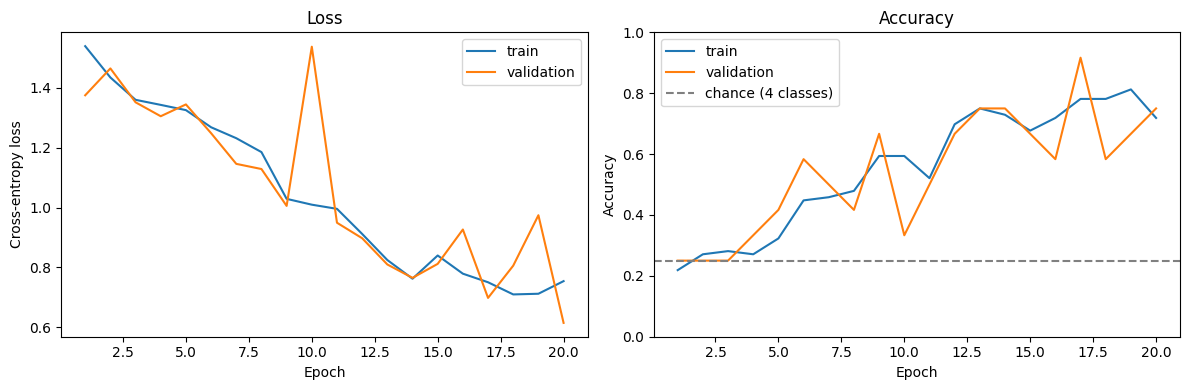

In [78]:
#TODO: your code here

import matplotlib.pyplot as plt

epochs = history["epoch"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="train")
axes[0].plot(epochs, history["val_loss"], label="validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs, history["train_acc"], label="train")
axes[1].plot(epochs, history["val_acc"], label="validation")
axes[1].axhline(0.25, linestyle="--", color="gray", label="chance (4 classes)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].set_title("Accuracy")
axes[1].legend()

fig.tight_layout()
plt.show()

## Module 4: Documenting research

**Student AI prompt challenge**
Design a prompt to save the resulting  train and validation losses and accuracies in a `.csv` file.

In [79]:
#TODO: your code here

import pandas as pd

history_df = pd.DataFrame(history)
out_csv = "training_history.csv"
history_df.to_csv(out_csv, index=False)

print(f"Saved {len(history_df)} epochs to {os.path.abspath(out_csv)}")
history_df.head()

Saved 20 epochs to /content/training_history.csv


,epoch,train_loss,train_acc,val_loss,val_acc
0,1,1.538765,0.218750,1.374769,0.250000
1,2,1.434270,0.270833,1.464481,0.250000
2,3,1.359657,0.281250,1.351341,0.250000
3,4,1.342723,0.270833,1.304825,0.333333
4,5,1.325238,0.322917,1.344285,0.416667


## Module 5: Additional prompt challenges

1. **Beat the Baseline:** Use AI to modify the CNN architecture (number of layers, kernel sizes, channels, pooling) and improve validation accuracy over the provided baseline.
2. **Try Different Optimizers:** Replace Adam with SGD, RMSprop, or AdamW. Compare convergence speed and final accuracy.
3. **Learning Rate Tuning:** Use AI to implement a learning rate scheduler (e.g., StepLR, CosineAnnealingLR, ReduceLROnPlateau) and determine whether it improves performance.
4. **Normalization Challenge:** Normalize the EEG channels (e.g., z-score using only the training subjects). Compare results with the unnormalized data.
5. **Confusion Matrix:** Compute and visualize the confusion matrix for the held-out subjects. Which conditions are most frequently confused?

Every challenge below is "change one thing, re-measure", so all of them use the
same three functions defined here:

* `make_folds` — splits the 27 subjects into groups of 3 for **leave-3-subjects-out
  cross-validation**. This matters: a single 3-subject split contains only 12
  samples, so one sample is worth 8.3 accuracy points and a "win" over the
  baseline can easily be noise. Averaging over folds is what makes the
  comparisons in this module meaningful.
* `train_one_fold` — trains a model for one fold given a config dictionary.
* `run_cv` — runs several folds and reports mean +/- std accuracy.

Set `N_FOLDS = 9` for the full cross-validation (every subject held out exactly
once). It defaults to 3 so the challenges finish quickly; use 9 for any result
you plan to report, and always on a GPU runtime.

In [80]:
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ----------------------------- config -----------------------------
SEED = 42
FOLD_SIZE = 3        # subjects held out per fold
N_FOLDS = 3          # set to 9 for full leave-3-subjects-out CV
EPOCHS_M5 = 20
BATCH_SIZE = 8

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

n_subjects, n_classes, n_channels, n_time = data.shape

# GAMEEMO: G1-G4 are the four games. The commonly documented emotion mapping is
# boring / calm / horror / funny - verify against the dataset README before you
# report emotion names rather than game numbers.
CLASS_NAMES = ["G1", "G2", "G3", "G4"]


def make_folds(n_subjects=n_subjects, fold_size=FOLD_SIZE, seed=SEED):
    """Partition subject indices into disjoint held-out groups."""
    rng = np.random.default_rng(seed)
    perm = rng.permutation(n_subjects)
    return [perm[i:i + fold_size] for i in range(0, n_subjects, fold_size)]


FOLDS = make_folds()
print(f"{len(FOLDS)} folds available, using the first {N_FOLDS}")


# ------------------------------ model -----------------------------
class EEGCNN(nn.Module):
    """1D CNN over time. Depth/width/kernels/pooling are all configurable so the
    architecture challenge only needs to change a dict."""

    def __init__(self, in_channels=n_channels, n_classes=n_classes,
                 conv_channels=(16, 32, 64), kernel_size=7, pool=4,
                 first_kernel=15, first_stride=4, dropout=0.3,
                 input_length=n_time):
        super().__init__()
        layers = []
        prev = in_channels
        L = input_length  # track the time-axis length as we go
        for i, ch in enumerate(conv_channels):
            k = first_kernel if i == 0 else kernel_size
            s = first_stride if i == 0 else 1
            layers += [
                nn.Conv1d(prev, ch, kernel_size=k, stride=s, padding=k // 2),
                nn.BatchNorm1d(ch),
                nn.ReLU(),
            ]
            L = (L + 2 * (k // 2) - k) // s + 1
            # Only pool while there is something left to pool. Aggressive
            # stride/pool combinations would otherwise drive the length to 0
            # and crash with "Invalid computed output size: 0".
            if L >= pool:
                layers.append(nn.MaxPool1d(pool))
                L = L // pool
            prev = ch
        assert L >= 1, "Time axis collapsed - reduce stride, pool, or depth"
        layers.append(nn.AdaptiveAvgPool1d(1))  # length-agnostic head
        self.features = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(dropout), nn.Linear(prev, n_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# --------------------------- factories ----------------------------
def make_optimizer(name, params, lr, weight_decay=0.0, momentum=0.9):
    name = name.lower()
    if name == "adam":
        return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    if name == "adamw":
        return torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay or 1e-2)
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=momentum,
                               weight_decay=weight_decay)
    if name == "rmsprop":
        return torch.optim.RMSprop(params, lr=lr, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {name}")


def make_scheduler(name, optimizer, epochs):
    if name in (None, "none"):
        return None
    name = name.lower()
    if name == "step":
        return torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, epochs // 3),
                                               gamma=0.1)
    if name == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    if name == "plateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                          factor=0.5, patience=3)
    raise ValueError(f"Unknown scheduler: {name}")


# ------------------------- data per fold --------------------------
def make_fold_loaders(val_subjects, normalize=False, batch_size=BATCH_SIZE):
    train_subjects = np.setdiff1d(np.arange(n_subjects), val_subjects)

    def to_xy(idx):
        X = data[idx].reshape(-1, n_channels, n_time).astype(np.float32)
        y = np.tile(np.arange(n_classes), len(idx)).astype(np.int64)
        return X, y

    X_tr, y_tr = to_xy(train_subjects)
    X_va, y_va = to_xy(val_subjects)

    if normalize:
        # z-score per channel using TRAINING subjects only - never touch the
        # held-out subjects when computing mu/sd, that would leak.
        mu = X_tr.mean(axis=(0, 2), keepdims=True)
        sd = X_tr.std(axis=(0, 2), keepdims=True) + 1e-8
        X_tr = (X_tr - mu) / sd
        X_va = (X_va - mu) / sd

    tr = DataLoader(TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)),
                    batch_size=batch_size, shuffle=True)
    va = DataLoader(TensorDataset(torch.from_numpy(X_va), torch.from_numpy(y_va)),
                    batch_size=batch_size, shuffle=False)
    return tr, va


# ------------------------- train one fold -------------------------
def train_one_fold(config, val_subjects, seed=SEED, verbose=False):
    torch.manual_seed(seed)
    np.random.seed(seed)

    train_loader, val_loader = make_fold_loaders(
        val_subjects, normalize=config.get("normalize", False)
    )

    model = EEGCNN(
        conv_channels=config.get("conv_channels", (16, 32, 64)),
        kernel_size=config.get("kernel_size", 7),
        pool=config.get("pool", 4),
        first_kernel=config.get("first_kernel", 15),
        first_stride=config.get("first_stride", 4),
        dropout=config.get("dropout", 0.3),
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(config.get("optimizer", "adam"), model.parameters(),
                               lr=config.get("lr", 1e-3),
                               weight_decay=config.get("weight_decay", 0.0))
    epochs = config.get("epochs", EPOCHS_M5)
    scheduler = make_scheduler(config.get("scheduler"), optimizer, epochs)

    history = {"epoch": [], "train_loss": [], "train_acc": [],
               "val_loss": [], "val_acc": [], "lr": []}

    def run(loader, train):
        model.train() if train else model.eval()
        loss_sum, correct, total = 0.0, 0, 0
        preds, targets = [], []
        with torch.set_grad_enabled(train):
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                if train:
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                p = logits.argmax(1)
                loss_sum += loss.item() * yb.size(0)
                correct += (p == yb).sum().item()
                total += yb.size(0)
                preds.append(p.cpu().numpy())
                targets.append(yb.cpu().numpy())
        return (loss_sum / total, correct / total,
                np.concatenate(preds), np.concatenate(targets))

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc, _, _ = run(train_loader, True)
        va_loss, va_acc, va_pred, va_true = run(val_loader, False)

        history["epoch"].append(epoch)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        if scheduler is not None:
            scheduler.step(va_loss) if config.get("scheduler") == "plateau" else scheduler.step()

        if verbose:
            print(f"  epoch {epoch:3d} | train {tr_loss:.4f}/{tr_acc:.3f} "
                  f"| val {va_loss:.4f}/{va_acc:.3f}")

    return history, va_true, va_pred


# ----------------------------- run CV -----------------------------
def run_cv(config, label, n_folds=N_FOLDS, verbose=False):
    t0 = time.time()
    accs, histories, all_true, all_pred = [], [], [], []

    for f, val_subjects in enumerate(FOLDS[:n_folds]):
        hist, y_true, y_pred = train_one_fold(config, val_subjects,
                                              seed=SEED + f, verbose=verbose)
        accs.append(hist["val_acc"][-1])
        histories.append(hist)
        all_true.append(y_true)
        all_pred.append(y_pred)

    accs = np.array(accs)
    result = {
        "label": label,
        "config": config,
        "fold_acc": accs,
        "mean_acc": accs.mean(),
        "std_acc": accs.std(),
        "histories": histories,
        "y_true": np.concatenate(all_true),
        "y_pred": np.concatenate(all_pred),
        "seconds": time.time() - t0,
    }
    print(f"{label:28s} | val acc {accs.mean():.3f} +/- {accs.std():.3f} "
          f"| folds {np.round(accs, 3)} | {result['seconds']:.0f}s")
    return result


# --------------------------- baseline -----------------------------
BASELINE = {
    "conv_channels": (16, 32, 64), "kernel_size": 7, "pool": 4,
    "first_kernel": 15, "first_stride": 4, "dropout": 0.3,
    "optimizer": "adam", "lr": 1e-3, "scheduler": None, "normalize": False,
    "epochs": EPOCHS_M5,
}

results = {}
results["baseline"] = run_cv(BASELINE, "baseline")
print(f"\nChance level = {1 / n_classes:.3f}")

Device: cuda
9 folds available, using the first 3
baseline                     | val acc 0.722 +/- 0.079 | folds [0.833 0.667 0.667] | 11s

Chance level = 0.250


### Challenge 1 — Beat the baseline

Four architecture variants against the baseline, each varying one axis: depth,
width, kernel size, and pooling/temporal resolution. Read the result as
`mean +/- std` across folds — a variant is only interesting if it clears the
baseline by more than roughly one standard deviation.

In [81]:
variants = {
    "deeper (4 blocks)":   {**BASELINE, "conv_channels": (16, 32, 64, 128)},
    "wider (32-64-128)":   {**BASELINE, "conv_channels": (32, 64, 128)},
    "long kernels (k=31)": {**BASELINE, "kernel_size": 15, "first_kernel": 31},
    "coarse pooling (8)":  {**BASELINE, "pool": 8, "first_stride": 8},
}

for name, cfg in variants.items():
    results[name] = run_cv(cfg, name)

# ---- summary table, sorted best first ----
import pandas as pd

arch_rows = [
    {"model": k, "mean_val_acc": v["mean_acc"], "std": v["std_acc"],
     "delta_vs_baseline": v["mean_acc"] - results["baseline"]["mean_acc"]}
    for k, v in results.items()
]
arch_df = pd.DataFrame(arch_rows).sort_values("mean_val_acc", ascending=False)
print()
display(arch_df.round(3))

best_name = arch_df.iloc[0]["model"]
BEST_ARCH = results[best_name]["config"]
print(f"\nBest architecture: {best_name}")

deeper (4 blocks)            | val acc 0.556 +/- 0.142 | folds [0.75  0.417 0.5  ] | 13s
wider (32-64-128)            | val acc 0.750 +/- 0.118 | folds [0.583 0.833 0.833] | 14s
long kernels (k=31)          | val acc 0.750 +/- 0.068 | folds [0.833 0.75  0.667] | 10s
coarse pooling (8)           | val acc 0.583 +/- 0.000 | folds [0.583 0.583 0.583] | 12s



,model,mean_val_acc,std,delta_vs_baseline
2,wider (32-64-128),0.750,0.118,0.028
3,long kernels (k=31),0.750,0.068,0.028
0,baseline,0.722,0.079,0.000
4,coarse pooling (8),0.583,0.000,-0.139
1,deeper (4 blocks),0.556,0.142,-0.167



Best architecture: wider (32-64-128)


### Challenge 2 — Optimizers

Adam, AdamW, SGD (momentum 0.9) and RMSprop on the best architecture from
Challenge 1. Note the different learning rates: SGD needs a much larger step
size than the adaptive methods, so comparing all four at `lr=1e-3` would be a
rigged test rather than a fair one.

"Convergence speed" is read off the training-loss curves — the epoch at which
each optimizer first reaches a fixed loss threshold.

optimizer=adam               | val acc 0.750 +/- 0.118 | folds [0.583 0.833 0.833] | 11s
optimizer=adamw              | val acc 0.750 +/- 0.118 | folds [0.583 0.833 0.833] | 10s
optimizer=sgd                | val acc 0.361 +/- 0.104 | folds [0.333 0.5   0.25 ] | 13s
optimizer=rmsprop            | val acc 0.722 +/- 0.171 | folds [0.5   0.917 0.75 ] | 10s



,optimizer,lr,mean_val_acc,std,epochs_to_train_loss<1.0,final_train_loss
0,adam,0.001,0.750,0.118,7.667,0.393
1,adamw,0.001,0.750,0.118,7.667,0.394
3,rmsprop,0.001,0.722,0.171,9.000,0.489
2,sgd,0.100,0.361,0.104,NaN,1.357


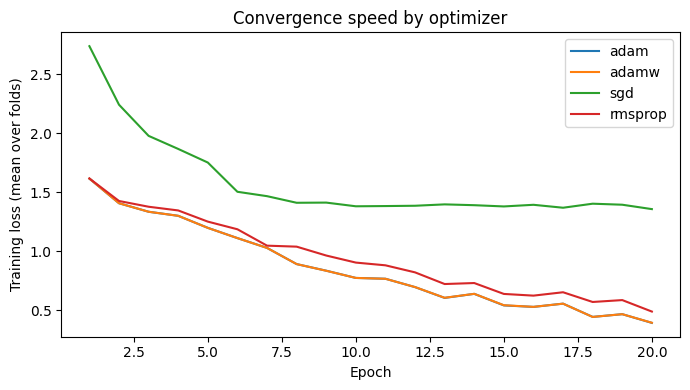

Best optimizer: adam


In [82]:
opt_settings = {
    "adam":    {"lr": 1e-3},
    "adamw":   {"lr": 1e-3, "weight_decay": 1e-2},
    "sgd":     {"lr": 1e-1},
    "rmsprop": {"lr": 1e-3},
}

opt_results = {}
for name, extra in opt_settings.items():
    cfg = {**BEST_ARCH, "optimizer": name, **extra}
    opt_results[name] = run_cv(cfg, f"optimizer={name}")


def epochs_to_reach(histories, key="train_loss", threshold=1.0):
    """Mean epoch at which a metric first crosses below threshold (NaN if never)."""
    hits = []
    for h in histories:
        below = [e for e, v in zip(h["epoch"], h[key]) if v < threshold]
        hits.append(below[0] if below else np.nan)
    return np.nanmean(hits) if not np.all(np.isnan(hits)) else np.nan


opt_df = pd.DataFrame([
    {"optimizer": k,
     "lr": v["config"]["lr"],
     "mean_val_acc": v["mean_acc"],
     "std": v["std_acc"],
     "epochs_to_train_loss<1.0": epochs_to_reach(v["histories"]),
     "final_train_loss": np.mean([h["train_loss"][-1] for h in v["histories"]])}
    for k, v in opt_results.items()
]).sort_values("mean_val_acc", ascending=False)
print()
display(opt_df.round(3))

# ---- convergence curves (fold-averaged training loss) ----
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
for name, v in opt_results.items():
    curve = np.mean([h["train_loss"] for h in v["histories"]], axis=0)
    plt.plot(v["histories"][0]["epoch"], curve, label=name)
plt.xlabel("Epoch"); plt.ylabel("Training loss (mean over folds)")
plt.title("Convergence speed by optimizer"); plt.legend(); plt.tight_layout(); plt.show()

BEST_OPT = opt_df.iloc[0]["optimizer"]
BEST_CFG = {**BEST_ARCH, "optimizer": BEST_OPT, **opt_settings[BEST_OPT]}
print(f"Best optimizer: {BEST_OPT}")

### Challenge 3 — Learning rate schedulers

`StepLR`, `CosineAnnealingLR` and `ReduceLROnPlateau` against a constant
learning rate. `ReduceLROnPlateau` is stepped with the validation loss while the
other two are stepped once per epoch — the harness already handles that
difference.

Watch for the classic failure mode: a scheduler that decays too early freezes
the model at a mediocre point, so a *lower* score here is a real result worth
reporting, not a bug.

scheduler=None               | val acc 0.750 +/- 0.118 | folds [0.583 0.833 0.833] | 10s
scheduler=step               | val acc 0.694 +/- 0.157 | folds [0.583 0.917 0.583] | 10s
scheduler=cosine             | val acc 0.889 +/- 0.039 | folds [0.917 0.917 0.833] | 10s
scheduler=plateau            | val acc 0.806 +/- 0.171 | folds [0.583 1.    0.833] | 10s



,scheduler,mean_val_acc,std,final_lr,final_val_loss
2,cosine,0.88889,0.03928,0.00001,0.49442
3,plateau,0.80556,0.17123,0.00100,0.52505
0,None,0.75000,0.11785,0.00100,0.58442
1,step,0.69444,0.15713,0.00000,0.86524


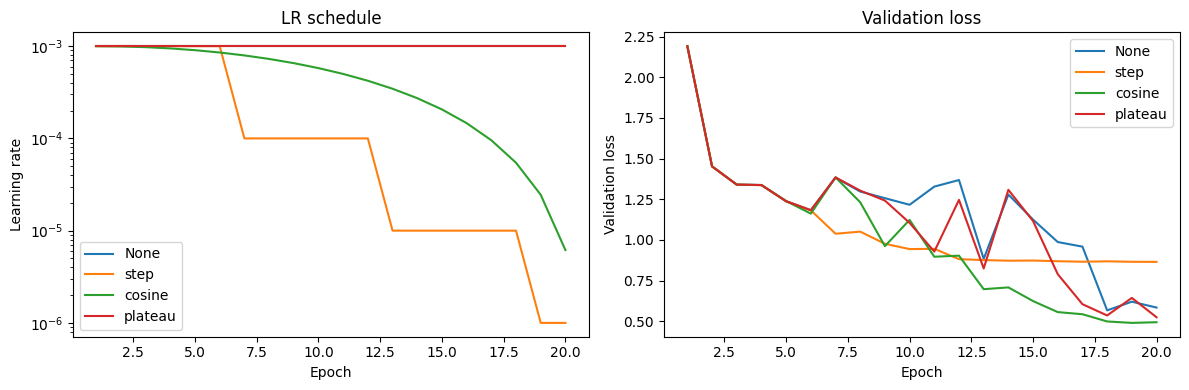

Best scheduler: cosine


In [83]:
sched_results = {}
for sched in [None, "step", "cosine", "plateau"]:
    cfg = {**BEST_CFG, "scheduler": sched}
    sched_results[str(sched)] = run_cv(cfg, f"scheduler={sched}")

sched_df = pd.DataFrame([
    {"scheduler": k, "mean_val_acc": v["mean_acc"], "std": v["std_acc"],
     "final_lr": v["histories"][0]["lr"][-1],
     "final_val_loss": np.mean([h["val_loss"][-1] for h in v["histories"]])}
    for k, v in sched_results.items()
]).sort_values("mean_val_acc", ascending=False)
print()
display(sched_df.round(5))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, v in sched_results.items():
    ep = v["histories"][0]["epoch"]
    axes[0].plot(ep, v["histories"][0]["lr"], label=name)
    axes[1].plot(ep, np.mean([h["val_loss"] for h in v["histories"]], axis=0), label=name)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Learning rate")
axes[0].set_yscale("log"); axes[0].set_title("LR schedule"); axes[0].legend()
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation loss")
axes[1].set_title("Validation loss"); axes[1].legend()
plt.tight_layout(); plt.show()

BEST_SCHED = sched_df.iloc[0]["scheduler"]
BEST_CFG = {**BEST_CFG, "scheduler": None if BEST_SCHED == "None" else BEST_SCHED}
print(f"Best scheduler: {BEST_SCHED}")

### Challenge 4 — Normalization

Per-channel z-scoring, with `mu` and `sd` computed **only from the training
subjects** of each fold and then applied to the held-out subjects. Computing
those statistics over the whole array before splitting would leak information
about the held-out subjects into training and inflate the score.

Raw EEG channels differ in scale and offset across subjects, so this is usually
where the largest single gain in this module comes from.

normalize=False              | val acc 0.889 +/- 0.039 | folds [0.917 0.917 0.833] | 10s
normalize=True               | val acc 0.861 +/- 0.079 | folds [0.917 0.917 0.75 ] | 12s



,normalized,mean_val_acc,std,fold_accs
0,False,0.888889,0.039284,"[0.917, 0.917, 0.833]"
1,True,0.861111,0.078567,"[0.917, 0.917, 0.75]"


Normalization changes mean validation accuracy by -0.028


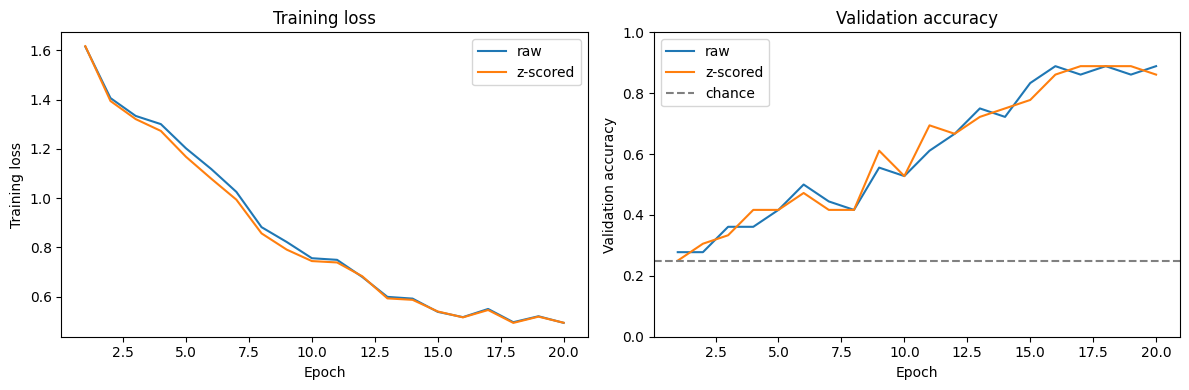


Final config: {'conv_channels': (32, 64, 128), 'kernel_size': 7, 'pool': 4, 'first_kernel': 15, 'first_stride': 4, 'dropout': 0.3, 'optimizer': 'adam', 'lr': 0.001, 'scheduler': 'cosine', 'normalize': False, 'epochs': 20}


In [84]:
norm_results = {}
for norm in [False, True]:
    cfg = {**BEST_CFG, "normalize": norm}
    norm_results[norm] = run_cv(cfg, f"normalize={norm}")

norm_df = pd.DataFrame([
    {"normalized": k, "mean_val_acc": v["mean_acc"], "std": v["std_acc"],
     "fold_accs": np.round(v["fold_acc"], 3)}
    for k, v in norm_results.items()
])
print()
display(norm_df)

gain = norm_results[True]["mean_acc"] - norm_results[False]["mean_acc"]
print(f"Normalization changes mean validation accuracy by {gain:+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for norm, v in norm_results.items():
    lbl = "z-scored" if norm else "raw"
    ep = v["histories"][0]["epoch"]
    axes[0].plot(ep, np.mean([h["train_loss"] for h in v["histories"]], axis=0), label=lbl)
    axes[1].plot(ep, np.mean([h["val_acc"] for h in v["histories"]], axis=0), label=lbl)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Training loss"); axes[0].legend()
axes[0].set_title("Training loss")
axes[1].axhline(1 / n_classes, ls="--", c="gray", label="chance")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation accuracy")
axes[1].set_ylim(0, 1); axes[1].set_title("Validation accuracy"); axes[1].legend()
plt.tight_layout(); plt.show()

FINAL_CFG = {**BEST_CFG, "normalize": bool(norm_df.sort_values("mean_val_acc").iloc[-1]["normalized"])}
print("\nFinal config:", FINAL_CFG)

### Challenge 5 — Confusion matrix

Run the **full 9-fold** cross-validation with the winning config so that every
subject is held out exactly once. That gives 27 x 4 = 108 predictions, each from
a model that never saw that subject — a far more stable confusion matrix than
the 12 predictions a single split would give.

Read it by row: row *i*, column *j* is how often true condition *i* was
predicted as *j*. The off-diagonal cells tell you which games the model cannot
tell apart.

final (all folds)            | val acc 0.843 +/- 0.092 | folds [0.917 0.917 0.833 0.833 1.    0.75  0.667 0.833 0.833] | 30s


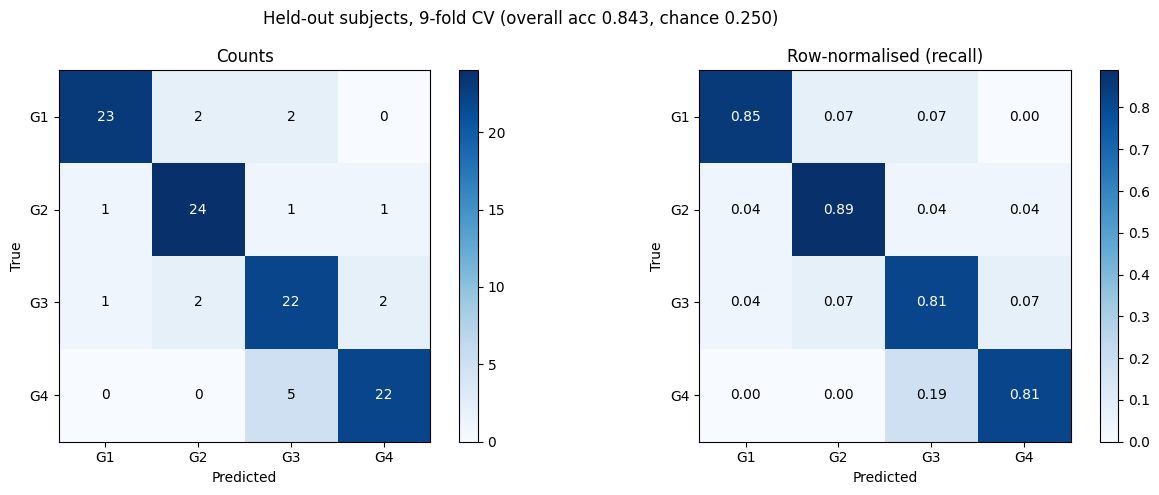

,class,support,recall,precision
0,G1,27,0.852,0.920
1,G2,27,0.889,0.857
2,G3,27,0.815,0.733
3,G4,27,0.815,0.880


Most frequent confusions (true -> predicted):
  G4 -> G3: 5 times (19% of G4)
  G1 -> G2: 2 times (7% of G1)
  G1 -> G3: 2 times (7% of G1)


In [85]:
final = run_cv(FINAL_CFG, "final (all folds)", n_folds=len(FOLDS))
y_true, y_pred = final["y_true"], final["y_pred"]

# ---- confusion matrix (no sklearn dependency) ----
cm = np.zeros((n_classes, n_classes), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

cm_norm = cm / cm.sum(axis=1, keepdims=True)   # row-normalised = per-class recall

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mat, title, fmt in [
    (axes[0], cm, "Counts", "d"),
    (axes[1], cm_norm, "Row-normalised (recall)", ".2f"),
]:
    im = ax.imshow(mat, cmap="Blues", vmin=0)
    ax.set_xticks(range(n_classes), CLASS_NAMES)
    ax.set_yticks(range(n_classes), CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    thresh = mat.max() / 2
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, format(mat[i, j], fmt), ha="center", va="center",
                    color="white" if mat[i, j] > thresh else "black")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(f"Held-out subjects, {len(FOLDS)}-fold CV "
             f"(overall acc {(y_true == y_pred).mean():.3f}, chance {1/n_classes:.3f})")
plt.tight_layout(); plt.show()

# ---- per-class precision / recall ----
per_class = pd.DataFrame({
    "class": CLASS_NAMES,
    "support": cm.sum(axis=1),
    "recall": np.diag(cm) / np.maximum(cm.sum(axis=1), 1),
    "precision": np.diag(cm) / np.maximum(cm.sum(axis=0), 1),
})
display(per_class.round(3))

# ---- most confused pairs ----
off = [(CLASS_NAMES[i], CLASS_NAMES[j], cm[i, j])
       for i in range(n_classes) for j in range(n_classes) if i != j]
off.sort(key=lambda r: -r[2])
print("Most frequent confusions (true -> predicted):")
for t, p, c in off[:3]:
    print(f"  {t} -> {p}: {c} times ({c / cm.sum(axis=1)[CLASS_NAMES.index(t)]:.0%} of {t})")

### Reporting your results

The cell below gathers every challenge table into one `module5_results.csv`,
plus the confusion matrix and the per-fold accuracies of the final model.

It is defensive on purpose: the four challenge tables have different columns, so
a plain `pd.concat` would produce a ragged frame, and `norm_df` holds numpy
arrays in `fold_accs` that do not round-trip through CSV. The cell normalises
each table to a shared schema, folds any extra scalar columns into a `notes`
string, and skips any challenge you have not run yet instead of raising
`NameError`.

Two caveats worth stating explicitly in your write-up:

* **The greedy search is not exhaustive.** Each challenge fixes the previous
  winner, so the final config is a good configuration, not the best one - the
  optimizer that wins on the baseline architecture may not be the one that wins
  on the deeper model.
* **108 samples is a small dataset for a CNN.** Even at 9 folds, differences of
  a few points between variants sit inside the fold-to-fold spread. Report the
  standard deviation alongside every mean, and resist claiming a winner when the
  intervals overlap.

In [87]:
# ---------------------------------------------------------------
# Module 5: collect every comparison into one CSV
# Safe to run even if you skipped some challenge cells above.
# ---------------------------------------------------------------
import os
import numpy as np
import pandas as pd

SUMMARY_COLS = ["challenge", "variant", "mean_val_acc", "std", "notes"]


def _collect(df_name, challenge, variant_col):
    """Normalise one challenge table into the shared summary schema."""
    df = globals().get(df_name)
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        print(f"  skipped '{challenge}' - {df_name} not found (cell not run?)")
        return None
    if variant_col not in df.columns:
        print(f"  skipped '{challenge}' - no '{variant_col}' column in {df_name}")
        return None

    out = pd.DataFrame({
        "challenge": challenge,
        "variant": df[variant_col].astype(str),
        "mean_val_acc": pd.to_numeric(df.get("mean_val_acc"), errors="coerce"),
        "std": pd.to_numeric(df.get("std"), errors="coerce"),
    })

    # Keep any extra scalar columns (lr, final_train_loss, ...) as a note string
    # instead of ragged columns. Array-valued columns like fold_accs are dropped
    # here because they do not round-trip through CSV.
    extras = [c for c in df.columns
              if c not in {variant_col, "mean_val_acc", "std", "challenge"}
              and df[c].map(lambda v: np.ndim(v) == 0).all()]
    if extras:
        out["notes"] = df[extras].round(4).astype(str).agg(
            lambda row: "; ".join(f"{c}={v}" for c, v in zip(extras, row)), axis=1
        ).values
    else:
        out["notes"] = ""
    return out


print("Collecting results:")
parts = [
    _collect("arch_df",  "1 architecture",  "model"),
    _collect("opt_df",   "2 optimizer",     "optimizer"),
    _collect("sched_df", "3 scheduler",     "scheduler"),
    _collect("norm_df",  "4 normalization", "normalized"),
]
parts = [p for p in parts if p is not None]

if parts:
    summary = pd.concat(parts, ignore_index=True)[SUMMARY_COLS]
    summary.to_csv("module5_results.csv", index=False)
    print(f"\nSaved {len(summary)} rows to {os.path.abspath('module5_results.csv')}")
    display(summary.round(3))
else:
    summary = pd.DataFrame(columns=SUMMARY_COLS)
    print("\nNothing to save - run the challenge cells first.")

# ---- confusion matrix (Challenge 5) ----
if "cm" in globals() and isinstance(cm, np.ndarray):
    names = globals().get("CLASS_NAMES", [f"class_{i}" for i in range(len(cm))])
    cm_df = pd.DataFrame(cm, index=[f"true_{n}" for n in names],
                         columns=[f"pred_{n}" for n in names])
    cm_df.to_csv("confusion_matrix.csv")
    print(f"Saved confusion matrix to {os.path.abspath('confusion_matrix.csv')}")
    display(cm_df)
else:
    print("Confusion matrix not found - run the Challenge 5 cell first.")

# ---- per-fold accuracies of the final model ----
if "final" in globals() and isinstance(globals()["final"], dict):
    folds_df = pd.DataFrame({
        "fold": range(1, len(final["fold_acc"]) + 1),
        "held_out_subjects": [", ".join(map(str, f)) for f in FOLDS[:len(final["fold_acc"])]],
        "val_acc": final["fold_acc"],
    })
    folds_df.to_csv("final_model_folds.csv", index=False)
    print(f"Saved per-fold accuracies to {os.path.abspath('final_model_folds.csv')}")
    display(folds_df.round(3))



Saved 15 rows to /content/module5_results.csv


,challenge,variant,mean_val_acc,std,notes
0,1 architecture,wider (32-64-128),0.750,0.118,delta_vs_baseline=0.0278
1,1 architecture,long kernels (k=31),0.750,0.068,delta_vs_baseline=0.0278
2,1 architecture,baseline,0.722,0.079,delta_vs_baseline=0.0
3,1 architecture,coarse pooling (8),0.583,0.000,delta_vs_baseline=-0.1389
4,1 architecture,deeper (4 blocks),0.556,0.142,delta_vs_baseline=-0.1667
5,2 optimizer,adam,0.750,0.118,lr=0.001; epochs_to_train_loss<1.0=7.6667; fin...
6,2 optimizer,adamw,0.750,0.118,lr=0.001; epochs_to_train_loss<1.0=7.6667; fin...
7,2 optimizer,rmsprop,0.722,0.171,lr=0.001; epochs_to_train_loss<1.0=9.0; final_...
8,2 optimizer,sgd,0.361,0.104,lr=0.1; epochs_to_train_loss<1.0=nan; final_tr...
9,3 scheduler,cosine,0.889,0.039,final_lr=0.0; final_val_loss=0.4944


Saved confusion matrix to /content/confusion_matrix.csv


,pred_G1,pred_G2,pred_G3,pred_G4
true_G1,23,2,2,0
true_G2,1,24,1,1
true_G3,1,2,22,2
true_G4,0,0,5,22


Saved per-fold accuracies to /content/final_model_folds.csv


,fold,held_out_subjects,val_acc
0,1,"7, 19, 22",0.917
1,2,"21, 17, 5",0.917
2,3,"15, 26, 18",0.833
3,4,"10, 9, 6",0.833
4,5,"16, 3, 0",1.000
5,6,"23, 20, 12",0.750
6,7,"11, 14, 25",0.667
7,8,"2, 4, 24",0.833
8,9,"1, 13, 8",0.833
